Otsu threshold (green): 94.00 | Otsu threshold (red): 48.00
Live Cells: 652 (66.13%)
Dead Cells: 334 (33.87%)


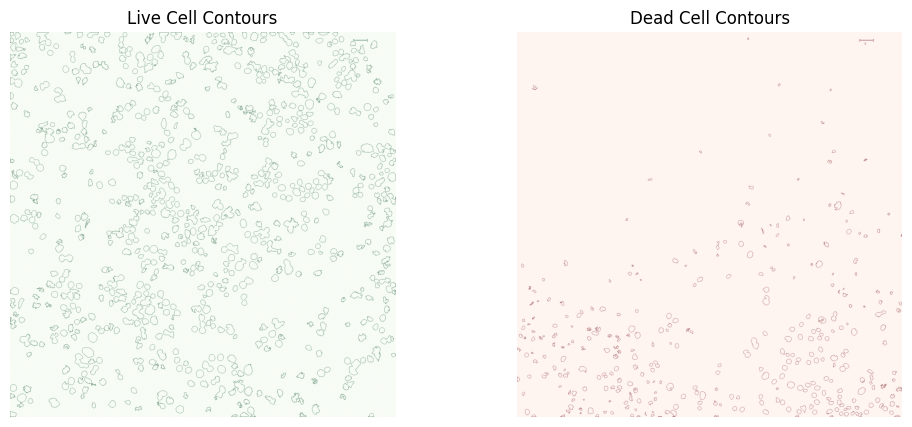

In [ ]:
# STEP 1: Install required packages
!pip install opencv-python-headless Pillow matplotlib ipywidgets

# STEP 2: Import libraries
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

# STEP 3: Upload the image
uploaded = files.upload()
filename = next(iter(uploaded))
img = Image.open(filename).convert('RGB')
img_np = np.array(img)

# Optional: Normalize if not 8-bit
if img_np.dtype != np.uint8:
    img_np = (255 * (img_np / np.max(img_np))).astype(np.uint8)

# STEP 4: Split channels
red_channel = img_np[:, :, 0]
green_channel = img_np[:, :, 1]

# STEP 5: Otsu thresholding
otsu_red, red_thresh = cv2.threshold(red_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsu_green, green_thresh = cv2.threshold(green_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# STEP 6: Counting function
def count_cells(binary_image, min_area, max_area, visualize=False):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [cnt for cnt in contours if min_area < cv2.contourArea(cnt) < max_area]

    if visualize:
        vis = np.zeros_like(binary_image)
        cv2.drawContours(vis, filtered, -1, 255, 1)
        return len(filtered), vis
    return len(filtered)

# STEP 7: Define widget sliders
live_min_area = widgets.IntSlider(value=80, min=10, max=300, step=10, description='Live Min Area')
live_max_area = widgets.IntSlider(value=3000, min=500, max=8000, step=100, description='Live Max Area')
dead_min_area = widgets.IntSlider(value=30, min=10, max=300, step=10, description='Dead Min Area')
dead_max_area = widgets.IntSlider(value=2000, min=500, max=8000, step=100, description='Dead Max Area')
run_button = widgets.Button(description="🔁 Recalculate", button_style='success')

# STEP 8: Callback function for button
def on_button_click(b):
    clear_output(wait=True)

    # Read current slider values
    lmin = live_min_area.value
    lmax = live_max_area.value
    dmin = dead_min_area.value
    dmax = dead_max_area.value

    # Recalculate
    dead_cells, red_vis = count_cells(red_thresh, dmin, dmax, visualize=True)
    live_cells, green_vis = count_cells(green_thresh, lmin, lmax, visualize=True)
    total_cells = live_cells + dead_cells
    live_percent = (live_cells / total_cells) * 100 if total_cells else 0
    dead_percent = (dead_cells / total_cells) * 100 if total_cells else 0

    # Show output
    print(f"Otsu threshold (green): {otsu_green:.2f} | Otsu threshold (red): {otsu_red:.2f}")
    print(f"Live Cells: {live_cells} ({live_percent:.2f}%)")
    print(f"Dead Cells: {dead_cells} ({dead_percent:.2f}%)")

    # Display contours
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(green_vis, cmap='Greens')
    plt.title('Live Cell Contours')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(red_vis, cmap='Reds')
    plt.title('Dead Cell Contours')
    plt.axis('off')
    plt.show()

    # Re-display controls
    display(widgets.VBox([
        widgets.HBox([live_min_area, live_max_area]),
        widgets.HBox([dead_min_area, dead_max_area]),
        run_button
    ]))

# STEP 9: Connect button
run_button.on_click(on_button_click)

# STEP 10: Display everything initially
display(widgets.VBox([
    widgets.HBox([live_min_area, live_max_area]),
    widgets.HBox([dead_min_area, dead_max_area]),
    run_button
]))
